In [1]:
import pickle
import numpy as np
# import casadi as ca
from timeit import default_timer as timer
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pyswarms.single.global_best import GlobalBestPSO
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from util import *
# from BayesOpt import *
from BayesOpt_torch import *
from myGP_torch import *
from examples.ex_fcn import *
import warnings
import logging
logging.disable(logging.CRITICAL)

#suppress warnings
warnings.filterwarnings('ignore')

# An example to test contextual Bayesian optimization


In [2]:
class polynomial(blackbox_fcn):
    def __init__(self):
        super().__init__()

    def evaluate_true(self, Z, T):
        T1, T2 = T
        Z1, Z2 = Z
        obj = Z1**3 + T1*Z1**2 + Z2**3 + T2*Z2**2 + 10*Z1*Z2
        
        # noise = np.random.normal(0, 0.01)
        return -obj.item()
    

In [3]:
# Bounds on the inputs variable
n_pts = 101
var_bounds = [(-5., 5.), (-5., 5.)]
# Bounds on the context variable
ctx_bounds = [(-5., 10.), (-8., 12.)]
true_fcn = polynomial()
NN_params = {"depth": 4, "neurons": 64}
training_params = {"max_iter": 200, "optimizer": "Adam", "num_restarts": 5}
CBO = Context_BayesOpt(2, 2, print_level=True, NN_params = NN_params, training_params=training_params)
CBO.set_feasible_set(var_bounds, ctx_bounds, n_pts)

In [4]:
OUTCOME = CBO.run_Outer(true_fcn, k_max = 30, k_init = 10, j_max = 30, j_init = 10, beta = 1e2, beta_rate=0.9, tol=1e-1, patience=3)

Iteration # 1
Sample the context: [ 2.2 -3.6]
Bayes Opt proposes to sample  [0.6 0.6]
Bayes Opt proposes to sample  [4.1 2.5]
Bayes Opt proposes to sample  [-4.2  1.8]
Bayes Opt proposes to sample  [-1.2 -2.4]
Bayes Opt proposes to sample  [0.1 2.3]
Bayes Opt proposes to sample  [-0.5 -4.1]
Bayes Opt proposes to sample  [ 4.1 -2.4]
Bayes Opt proposes to sample  [-2.2  4.1]
Bayes Opt proposes to sample  [1.5 1.5]
Bayes Opt proposes to sample  [4.1 3.3]
Bayes Opt proposes to sample  [-2.53301734  0.3323701 ]
Bayes Opt proposes to sample  [1.60566932 0.7041003 ]
Bayes Opt proposes to sample  [-3.73638123 -2.10508049]
Bayes Opt proposes to sample  [0.28556813 0.83945896]
Bayes Opt proposes to sample  [-0.74809306 -1.1250326 ]
Bayes Opt proposes to sample  [ 0.9586509  -1.42624442]
Bayes Opt proposes to sample  [-3.54199925 -0.45306754]
Bayes Opt proposes to sample  [0.46141041 2.32642855]
Bayes Opt proposes to sample  [-0.80706955  4.31536767]
Bayes Opt proposes to sample  [2.75047353 4.37

In [17]:
CBO.GP_s.training_params = {"max_iter": 200, "optimizer": "Adam", "num_restarts": 5}
CBO.GP_s._train_gp(CBO.GP_s.X, CBO.GP_s.Y)

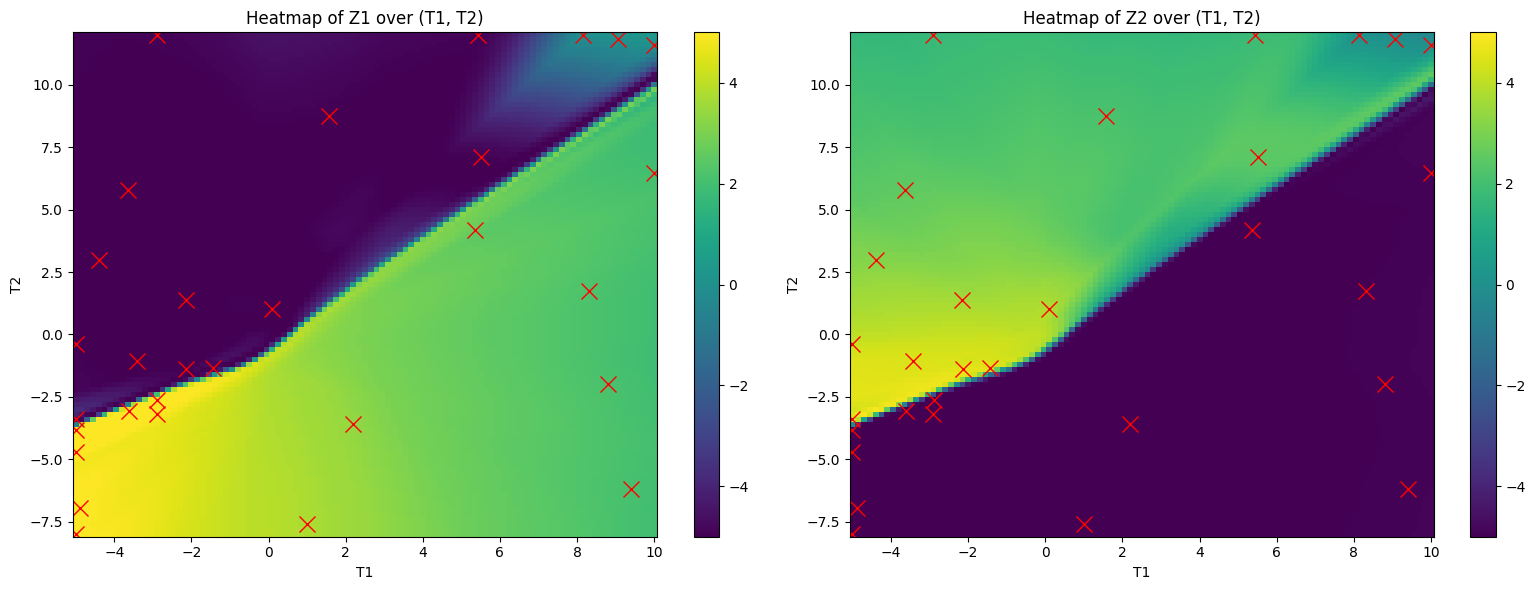

In [19]:
# Separate TT into T1, T2
T1 = CBO.TT[:, 0]
T2 = CBO.TT[:, 1]

Z_GP, _ = CBO.GP_s.predict(CBO.TT)
Z1 = Z_GP[:,0]; Z2 = Z_GP[:,1]
# Create a figure with two subplots (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot the first heatmap in the first subplot
c1 = axs[0].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z1.reshape(n_pts, n_pts),
                       shading='auto', vmin=var_bounds[0][0], vmax=var_bounds[0][1])
axs[0].set_xlabel('T1')
axs[0].set_ylabel('T2')
axs[0].set_title('Heatmap of Z1 over (T1, T2)')
axs[0].plot(CBO.GP_s.X[:,0].cpu().numpy(), CBO.GP_s.X[:,1].cpu().numpy(), 'rx', markersize = 12)
fig.colorbar(c1, ax=axs[0])

# Plot the second heatmap in the second subplot
c2 = axs[1].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z2.reshape(n_pts, n_pts),
                       shading='auto', vmin=var_bounds[1][0], vmax=var_bounds[1][1])
axs[1].set_xlabel('T1')
axs[1].set_ylabel('T2')
axs[1].set_title('Heatmap of Z2 over (T1, T2)')
axs[1].plot(CBO.GP_s.X[:,0].cpu().numpy(), CBO.GP_s.X[:,1].cpu().numpy(), 'rx', markersize = 12)
fig.colorbar(c2, ax=axs[1])


# Show the plot
plt.tight_layout()
plt.show()

# Ground-truth from a solver

In [21]:
# # Using differential evolution and L-BFGS-B optimizer from SciPy
# from scipy.optimize import differential_evolution
# sample_T = CBO.TT
# best_Zsol = []

# for T in sample_T:
#     def obj(Z):
#         return -true_fcn.evaluate_true(Z, T)
#     # First global optimization
#     result_de = differential_evolution(obj, var_bounds)
#     # Then local refinement
#     res = minimize(obj, result_de.x, method='L-BFGS-B', bounds=var_bounds)
#     best_Zsol.append(res.x)

# best_Zsol = np.array(best_Zsol)

In [22]:
# Second option: using PSO optimizer
best_Zsol = []
sample_T = CBO.TT

# instantiate the optimizer
x_max = CBO.ZZ[-1]
x_min = CBO.ZZ[0]
bounds = (x_min, x_max)
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

for T in sample_T:
    # Define objective function for given T
    def objective(Z_particles):
        return -np.array([true_fcn.evaluate_true(Z, T) for Z in Z_particles])
    
    # Initialize PSO optimizer
    optimizer = GlobalBestPSO(n_particles=30, dimensions=2, options=options, bounds=bounds)
    # Run PSO to find global minimizer
    cost, pos = optimizer.optimize(objective, iters=100, verbose=False)

    # Add local refinement
    def single_obj(Z):
        return -true_fcn.evaluate_true(Z, T)

    res = minimize(single_obj, pos, method='L-BFGS-B', bounds=list(zip(x_min, x_max)))
    best_Zsol.append(res.x)

best_Zsol = np.array(best_Zsol)


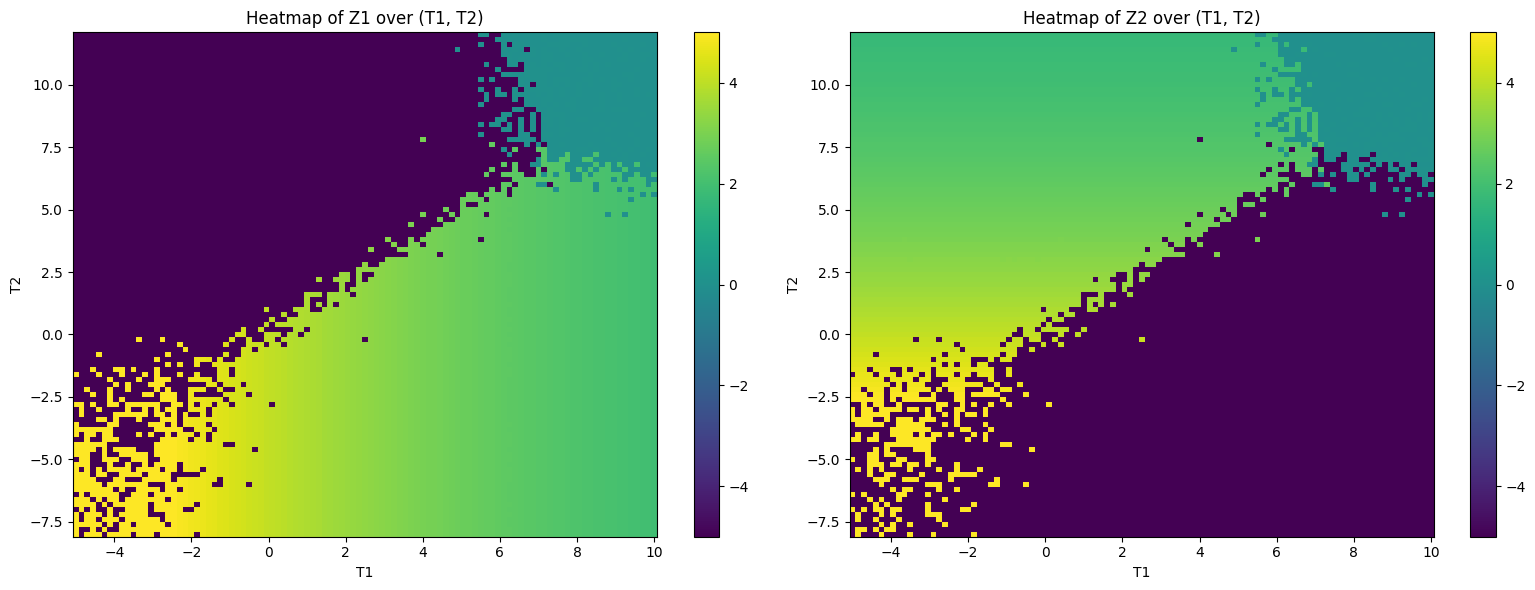

In [23]:
# Separate TT into T1, T2
T1 = sample_T[:, 0]
T2 = sample_T[:, 1]

# Separate Z into Z1, Z2
Z1 = best_Zsol[:, 0]
Z2 = best_Zsol[:, 1]

# Create a figure with two subplots (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot the first heatmap (Z1) in the first subplot
c1 = axs[0].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z1.reshape(n_pts, n_pts),
                       shading='auto', vmin=var_bounds[0][0], vmax=var_bounds[0][1])
axs[0].set_xlabel('T1')
axs[0].set_ylabel('T2')
axs[0].set_title('Heatmap of Z1 over (T1, T2)')
fig.colorbar(c1, ax=axs[0])

# Plot the second heatmap (Z2) in the second subplot
c2 = axs[1].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z2.reshape(n_pts, n_pts),
                       shading='auto', vmin=var_bounds[1][0], vmax=var_bounds[1][1]) 
axs[1].set_xlabel('T1')
axs[1].set_ylabel('T2')
axs[1].set_title('Heatmap of Z2 over (T1, T2)')
fig.colorbar(c2, ax=axs[1])

# Adjust layout for better spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()